# Этап 3 — Предсказание: реальное или нереальное блюдо

**Задача:** отличить настоящий рецепт от фейкового (ингредиенты перемешаны из разных блюд).

**Сводное сравнение (§3.8.1)** — три метода на **hard**-негативах (PPR), ингредиентный сигнал:
1. **LogReg** — несовместимость, `odd_min_score`, |ингредиентов| в `I_train`;
2. **GraphSAGE** — inductive GNN;
3. **HeteroGAT** — transductive GAT.

Плотность связей — только §3.3.1 (шорткат на easy). §3.4 — протокол и ablation признаков.

**Протокол:** LogReg и GraphSAGE — `I_train`. HeteroGAT §3.8 — полный `I` + `feat_df` из nb02.


In [1]:
import ast
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

import gnn_graph_classification
import ingredient_ru

importlib.reload(ingredient_ru)
importlib.reload(gnn_graph_classification)

from gnn_graph_classification import incompatible_pairs, make_fake_recipes
from ingredient_ru import filter_ingredients, preload_pool, ru, ru_list

OUT = Path('output_graphs')
DATA = Path('full_dataset.csv')
if not DATA.exists():
 DATA = Path('data_sample.csv')
SEED = 42

print('Готово')

Готово


## 3.1 Загрузка графа и рецептов

In [2]:
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
ing_set = {str(x) for x in I.nodes()}

importlib.reload(ingredient_ru)
from ingredient_ru import preload_pool
ingredient_ru._RUNTIME_RU.clear()
n_tr = preload_pool(ing_set)
print(f'Ингредиентов в графе: {len(ing_set):,} (переведено: {n_tr:,})')

df = pd.read_csv(DATA, nrows=8000, usecols=['NER'])

recipes = []
for s in df['NER']:
    try:
        ings = [str(x).strip().lower() for x in ast.literal_eval(s) if isinstance(x, str)]
        ings = filter_ingredients(x for x in ings if x in ing_set)
        if len(ings) >= 3:
            recipes.append(ings)
    except Exception:
        pass

print(f'Рецептов: {len(recipes):,}')


Ингредиентов в графе: 7,199 (переведено: 4,757)
Рецептов: 7,807


## 3.2 Метки: реальные и фейковые рецепты

**Реальные** — рецепты из датасета. **Фейковые** — ≈50% ингредиентов заменены случайными.

In [3]:
# Метки: реальные (из датасета) + фейковые (≈50% ингредиентов заменены случайными)
fake = make_fake_recipes(recipes, ingredient_pool=sorted(ing_set), mix_ratio=0.5, seed=SEED)
y_real = np.ones(len(recipes))
y_fake = np.zeros(len(fake))

print(f'Реальных: {len(recipes):,} | фейковых: {len(fake):,}')

Реальных: 7,807 | фейковых: 7,807


## 3.3 Первый простой способ: сочетаются ли ингредиенты?

В нормальном рецепте продукты обычно уже видели вместе в других блюдах. В выдуманном рецепте часто попадают пары, которые вместе почти никогда не использовались.

Что делаем:

1. Делим рецепты на две части — на одной учимся, на другой проверяем. Список «кто с кем сочетается» собираем только из учебной части.
2. Для каждого рецепта считаем три признака: долю несовместимых пар, `odd_min_score` (насколько «чужой» самый изолированный ингредиент) и число ингредиентов. По ним LogReg отличает настоящий рецепт от фейка.

На этапе 1 список связей построен на всём датасете — там тысячи ингредиентов. Здесь около шести тысяч рецептов для учёбы, в списке остаётся около трёхсот. Если дальше результат ниже — это в основном потому, что список короче. Сравнение вариантов — в §3.3.1′.


In [4]:
from recipe_negatives import build_cooc_graph, edge_density

recipes_tr, recipes_te = train_test_split(recipes, test_size=0.2, random_state=SEED)

MIN_FREQ_TR, MIN_COOC_TR = 20, 5
I_train = build_cooc_graph(recipes_tr, min_freq=MIN_FREQ_TR, min_cooc=MIN_COOC_TR)
print(f'train: {len(recipes_tr):,} test: {len(recipes_te):,} | '
      f'I_train: {I_train.number_of_nodes():,} узлов, {I_train.number_of_edges():,} рёбер')

fake_tr = make_fake_recipes(recipes_tr, ingredient_pool=sorted(ing_set), mix_ratio=0.5, seed=SEED)
fake_te = make_fake_recipes(recipes_te, ingredient_pool=sorted(ing_set), mix_ratio=0.5, seed=SEED + 1)

def _n_pairs(r):
    n = len(r)
    return n * (n - 1) // 2 if n > 1 else 0

def incompat_frac(r, graph):
    p = _n_pairs(r)
    return len(incompatible_pairs(r, graph)) / p if p else 0.0

def odd_min_score(r, graph):
    """Мин. среднее число общих соседей — самый «чужой» ингредиент (уникальные)."""
    ings = list(dict.fromkeys(x for x in r if x in graph))
    if len(ings) < 2:
        return 0.0
    scores = []
    for ing in ings:
        others = [x for x in ings if x != ing]
        if not others:
            continue
        cn = sum(len(set(graph.neighbors(ing)) & set(graph.neighbors(o))) for o in others)
        scores.append(cn / len(others))
    return min(scores) if scores else 0.0

def features(rec_list, graph):
    return np.array([[incompat_frac(r, graph), odd_min_score(r, graph), len(r)]
                     for r in rec_list])

def density_features(rec_list, graph):
    """§3.3.1 — шорткат плотности."""
    return np.array([[edge_density(r, graph), len(r)] for r in rec_list])

X_tr = np.vstack([features(recipes_tr, I_train), features(fake_tr, I_train)])
y_tr = np.r_[np.ones(len(recipes_tr)), np.zeros(len(fake_tr))]
X_te = np.vstack([features(recipes_te, I_train), features(fake_te, I_train)])
y_te = np.r_[np.ones(len(recipes_te)), np.zeros(len(fake_te))]

clf = LogisticRegression(max_iter=500).fit(X_tr, y_tr)
pred = clf.predict(X_te)
print(f'LogReg(несовм.+odd_min+|ингр.|): acc={accuracy_score(y_te, pred):.3f} '
      f'AUC={roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]):.3f}')
print(classification_report(y_te, pred, target_names=['нереальное', 'реальное']))


train: 6,245 test: 1,562 | I_train: 279 узлов, 4,467 рёбер
LogReg(несовм.+odd_min+|ингр.|): acc=0.884 AUC=0.938
              precision    recall  f1-score   support

  нереальное       0.85      0.93      0.89      1562
    реальное       0.92      0.84      0.88      1562

    accuracy                           0.88      3124
   macro avg       0.89      0.88      0.88      3124
weighted avg       0.89      0.88      0.88      3124



### 3.3.1 Иллюстрация шортката: плотность на easy-негативах

Отдельный одномерный признак — **доля связных пар** (плотность), без `odd_min` и длины.
Для одного скаляра плотность = 1 − несовместимость, поэтому LogReg даёт тот же AUC, что и «только несовм.» в §3.4.

На easy-фейках метрики завышены: модель выучивает «связно = настоящее».
На hard (§3.3.4) шорткат **ломается** — PPR-фейки плотные, но не отличимы по одному скаляру от реальных.


In [5]:
def eval_density_shortcut(graph, tag):
    Xtr = np.vstack([density_features(recipes_tr, graph), density_features(fake_tr, graph)])
    ytr = np.r_[np.ones(len(recipes_tr)), np.zeros(len(fake_tr))]
    Xte = np.vstack([density_features(recipes_te, graph), density_features(fake_te, graph)])
    yte = np.r_[np.ones(len(recipes_te)), np.zeros(len(fake_te))]
    c   = LogisticRegression(max_iter=500).fit(Xtr, ytr)
    acc = accuracy_score(yte, c.predict(Xte))
    auc = roc_auc_score(yte, c.predict_proba(Xte)[:, 1])
    print(f'[{tag}] acc={acc:.3f} AUC={auc:.3f}')
    return dict(tag=tag, acc=acc, auc=auc)

print('Плотность (easy-негативы, сплит §3.3):')
res_dens_I     = eval_density_shortcut(I,      'полный граф (этап 1)')
res_dens_train = eval_density_shortcut(I_train, 'граф из обучения')
print(f'\nДля сравнения — baseline §3.3 (несовместимые пары): AUC={roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]):.3f}')
display(pd.DataFrame([res_dens_I, res_dens_train]).round(3))


Плотность (easy-негативы, сплит §3.3):
[полный граф (этап 1)] acc=0.968 AUC=0.989
[граф из обучения] acc=0.873 AUC=0.926

Для сравнения — baseline §3.3 (несовместимые пары): AUC=0.938


,tag,acc,auc
0,полный граф (этап 1),0.968,0.989
1,граф из обучения,0.873,0.926


### 3.3.1′ Почему на маленьком списке связей результат ниже

Сравниваем большой список из всего датасета и маленький — только из учебных рецептов. Разница может быть из трёх причин:

- в маленький список не входят проверочные рецепты;
- здесь меньше рецептов, чем на этапе 1;
- редкие ингредиенты и пары отбрасываются — на маленькой выборке отсекается больше.

Колонка «плотность» — одномерный шорткат (§3.3.1); «ingredient-baseline» — три признака из §3.3.


In [6]:
# === §3.3.1′: сравнение графов разного размера ===
def _auc_on_graph(graph, feat_fn=density_features):
    Xtr = np.vstack([feat_fn(recipes_tr, graph), feat_fn(fake_tr, graph)])
    ytr = np.r_[np.ones(len(recipes_tr)), np.zeros(len(fake_tr))]
    Xte = np.vstack([feat_fn(recipes_te, graph), feat_fn(fake_te, graph)])
    yte = np.r_[np.ones(len(recipes_te)), np.zeros(len(fake_te))]
    c = LogisticRegression(max_iter=500).fit(Xtr, ytr)
    return roc_auc_score(yte, c.predict_proba(Xte)[:, 1])

# граф на всей выборке nb03 (список богаче, чем только из train)
I_all = build_cooc_graph(recipes, min_freq=MIN_FREQ_TR, min_cooc=MIN_COOC_TR)

rows_decomp = [
    {'вариант': 'большой граф (этап 1)', 'ингредиентов': I.number_of_nodes(),
     'связей': I.number_of_edges(),      'качество (шорткат: плотность)': _auc_on_graph(I),
     'качество (ingredient-baseline)': _auc_on_graph(I, features)},
    {'вариант': f'выборка nb03 ({len(recipes):,} рецептов)',
     'ингредиентов': I_all.number_of_nodes(), 'связей': I_all.number_of_edges(),
     'качество (шорткат: плотность)': _auc_on_graph(I_all), 'качество (ingredient-baseline)': _auc_on_graph(I_all, features)},
    {'вариант': 'только учебные рецепты',
     'ингредиентов': I_train.number_of_nodes(), 'связей': I_train.number_of_edges(),
     'качество (шорткат: плотность)': res_dens_train['auc'],
     'качество (ingredient-baseline)': roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])},
]

for mf, mc in [(50, 10), (20, 5), (10, 3), (5, 2)]:
    g = build_cooc_graph(recipes_tr, min_freq=mf, min_cooc=mc)
    rows_decomp.append({
        'вариант': f'учебные, пороги {mf}/{mc}', 'ингредиентов': g.number_of_nodes(),
        'связей': g.number_of_edges(), 'качество (шорткат: плотность)': _auc_on_graph(g),
        'качество (ingredient-baseline)': _auc_on_graph(g, features),
    })

decomp = pd.DataFrame(rows_decomp)
display(decomp.round(3))


,вариант,ингредиентов,связей,качество (шорткат: плотность),качество (ingredient-baseline)
0,большой граф (этап 1),7199,418645,0.989,0.992
1,"выборка nb03 (7,807 рецептов)",327,5504,0.943,0.951
2,только учебные рецепты,279,4467,0.926,0.938
3,"учебные, пороги 50/10",143,1994,0.884,0.899
4,"учебные, пороги 20/5",279,4467,0.926,0.938
5,"учебные, пороги 10/3",463,8275,0.951,0.956
6,"учебные, пороги 5/2",689,13627,0.964,0.967


### 3.3.2 Hard negatives через Personalized PageRank

Делаем **near-miss** негативы: заменяем часть ингредиентов на PPR-*соседние* (по отдельности правдоподобные), пропуская самые верхние PPR-хиты (они сочетаемы). 

In [7]:
# === Блок B-1: hard negatives (PPR) и их сравнение с easy ===
from recipe_negatives import make_hard_fake_recipes

# PPR берём подвыборку pagerank на рецепт
N_HARD = 600
sub_tr = recipes_tr[:N_HARD]
sub_te = recipes_te[:max(1, N_HARD // 4)]

# hard негативы — на train-only графе
hard_tr = make_hard_fake_recipes(sub_tr, I_train, ing_set, mix_ratio=0.4, seed=SEED)
hard_te = make_hard_fake_recipes(sub_te, I_train, ing_set, mix_ratio=0.4, seed=SEED + 1)

# easy негативы на той же подвыборке — для сравнения
easy_tr = make_fake_recipes(sub_tr, ingredient_pool=sorted(ing_set), mix_ratio=0.5, seed=SEED)
easy_te = make_fake_recipes(sub_te, ingredient_pool=sorted(ing_set), mix_ratio=0.5, seed=SEED + 1)

def eval_negs(neg_tr, neg_te, tag):
 Xtr = np.vstack([features(sub_tr, I_train), features(neg_tr, I_train)])
 ytr = np.r_[np.ones(len(sub_tr)), np.zeros(len(neg_tr))]
 Xte = np.vstack([features(sub_te, I_train), features(neg_te, I_train)])
 yte = np.r_[np.ones(len(sub_te)), np.zeros(len(neg_te))]
 clf = LogisticRegression(max_iter=500).fit(Xtr, ytr)
 acc = accuracy_score(yte, clf.predict(Xte))
 auc = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])
 print(f'[{tag:>18}] ingredient LogReg acc={acc:.3f} AUC={auc:.3f}')
 return dict(neg=tag, acc=acc, auc=auc)

print('Сложность негативов (граф I_train):')
r_easy = eval_negs(easy_tr, easy_te, 'easy (случайные)')
r_hard = eval_negs(hard_tr, hard_te, 'hard (PPR)')
display(pd.DataFrame([r_easy, r_hard]).round(3))

print('\nПример:')
print(' реальный :', ru_list(sub_tr[0]))
print(' hard-fake:', ru_list(hard_tr[0]))

Сложность негативов (граф I_train):
[  easy (случайные)] ingredient LogReg acc=0.903 AUC=0.941
[        hard (PPR)] ingredient LogReg acc=0.583 AUC=0.621


,neg,acc,auc
0,easy (случайные),0.903,0.941
1,hard (PPR),0.583,0.621



Пример:
 реальный : ['мука', 'сахар', 'семена тмина', 'сода', 'разрыхлитель', 'сливочное масло', 'изюм', 'соль', 'простокваша', 'яйцо']
 hard-fake: ['коричневый сахар', 'сахар', 'семена тмина', 'сода', 'корица', 'перец', 'маргарин', 'соль', 'простокваша', 'яйцо']


### 3.3.3 LLM-верификация негативов

PPR-замены *в среднем* делают рецепт неправдоподобным, но часть остаётся вполне готовимой. 
Используем LLM DeepSeek и спрашиваем, можно ли это приготовить, и оставляем подтверждённые **«невозможные»** как качественные hard-негативы.

Доля «невозможных» в §3.3.3 **плавает между прогонами** (обычно 32–38%): ячейка ходит в API без кэша, в отличие от §3.3.5 (`negative_corpus.json`). В шпаргалке — цифра из финального прогона.


In [8]:
# === LLM-верификация hard-негативов (DeepSeek) ===
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from recipe_negatives import verify_negatives_llm

def _load_dotenv(path='.env'):
    p = Path(path)
    if not p.exists():
        return
    for line in p.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

_load_dotenv()
API_KEY = os.environ.get('DEEPSEEK_API_KEY')

N_VERIFY = min(100, len(hard_te))
sample = [filter_ingredients(r) for r in hard_te[:N_VERIFY]]
res = verify_negatives_llm(sample, ru_fn=ru, api_key=API_KEY)

if res is None:
    print('Токен не задан — верификация пропущена.')
else:
    imp = res['impossible_idx']
    print(f'Проверено: {len(sample)} | съедобных (отброшено): {len(sample) - len(imp)} '
          f'| КАЧЕСТВЕННЫХ hard-негативов: {len(imp)} ({res["frac_impossible"]:.0%})')

    quality = pd.DataFrame({
        '№': [i + 1 for i in imp],
        'ингр.': [len(sample[i]) for i in imp],
        'невозможная комбинация ингредиентов': [', '.join(ru_list(sample[i])) for i in imp],
    }).set_index('№')
    print('\nКачественные hard-негативы — LLM подтвердила, что приготовить нельзя:')
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
        display(quality.style.set_properties(
            subset=['невозможная комбинация ингредиентов'],
            **{'white-space': 'normal', 'text-align': 'left'}))

    md = [f'# Вердикт DeepSeek\nКачественных (невозможных): **{len(imp)}/{len(sample)}**\n']
    for k, r in enumerate(sample):
        v = 'НЕВОЗМОЖНО' if res['verdicts'][k] else 'возможно'
        md.append(f'## {k + 1}. {v} ({len(r)} ингр.)\n' + ', '.join(ru_list(r)) + '\n')
    (OUT / 'llm_hard_verdicts.md').write_text('\n'.join(md), encoding='utf-8')
    print('\nПолный список (вкл. съедобные) сохранён:', (OUT / 'llm_hard_verdicts.md').resolve())


  обработано 8/100
  обработано 16/100
  обработано 24/100
  обработано 32/100
  обработано 40/100
  обработано 48/100
  обработано 56/100
  обработано 64/100
  обработано 72/100
  обработано 80/100
  обработано 88/100
  обработано 96/100
  обработано 100/100
Проверено: 100 | съедобных (отброшено): 68 | КАЧЕСТВЕННЫХ hard-негативов: 32 (32%)

Качественные hard-негативы — LLM подтвердила, что приготовить нельзя:


,ингр.,невозможная комбинация ингредиентов
№,,
17,6,"обеденные булочки, белый сахар, молоко, пекан, карамельный пудинг, лук"
19,9,"сливочное масло, лук, разрыхлитель, перец, молоко, горчица, сливки херес, вода, ваниль"
21,6,"апельсиновый кекс, лук, масло для салата, яйца, орехи, ваниль"
23,8,"кочан капусты, замороженный горох, соль, ваниль, вода, имбирная паста, молоко, куркума"
28,5,"жёлтый кекс, коричневый сахар, лук, сливочное масло, вода"
30,5,"молоко, рис, фритюрница, сливочное масло, вода"
31,7,"клюква, молоко, лимон, ваниль, лук, яблоки, апельсины"
32,4,"сливочное масло, арахисовая паста, молоко, лук"
34,9,"фарш говяжий, яблочный уксус, ваниль, вода, изюм без косточек, разрыхлитель, кипяток, душистый перец, молоко"



Полный список (вкл. съедобные) сохранён: /Users/valeriia_reznik/SNA Magolego/output_graphs/llm_hard_verdicts.md


### 3.3.4 Тест на перенос (easy → hard)

Модели обучены на **easy**-фейках (random mix). На **hard** (PPR) и LLM-confirmed перенос ломает все методы:
LogReg и GraphSAGE падают ниже случайного уровня на PPR; одномерная плотность тоже < 0.5.

Вывод не «GNN устойчив к переносу», а «без hard в обучении easy→hard не работает». Когда hard есть в train (§3.8.1, §3.9), GraphSAGE обгоняет LogReg.



In [9]:
# === Стресс-тест: ingredient-baseline vs GraphSAGE (easy → hard) ===
import torch
from gnn_graph_classification import train_graphsage_validity_inductive, recipes_to_hetero

if res is None:
    print('Нет вердиктов DeepSeek — стресс-тест по confirmed пропущен; easy/hard сравним.')

real_tr, real_te = sub_tr, sub_te
easy_eval = [filter_ingredients(r) for r in easy_te[:N_VERIFY]]
neg_sets = {'easy (random)': easy_eval, 'hard (PPR)': sample}
if res is not None and res['impossible_idx']:
    neg_sets['hard, LLM-confirmed'] = [sample[i] for i in res['impossible_idx']]

Xtr_ing = np.vstack([features(real_tr, I_train), features(easy_tr, I_train)])
ytr = np.r_[np.ones(len(real_tr)), np.zeros(len(easy_tr))]
clf_ing_ss = LogisticRegression(max_iter=500).fit(Xtr_ing, ytr)

def ing_auc(neg):
    X = np.vstack([features(real_te, I_train), features(neg, I_train)])
    y = np.r_[np.ones(len(real_te)), np.zeros(len(neg))]
    return roc_auc_score(y, clf_ing_ss.predict_proba(X)[:, 1])

Xtr_d = np.vstack([density_features(real_tr, I_train), density_features(easy_tr, I_train)])
clf_dens_ss = LogisticRegression(max_iter=500).fit(Xtr_d, ytr)

def dens_auc(neg):
    X = np.vstack([density_features(real_te, I_train), density_features(neg, I_train)])
    y = np.r_[np.ones(len(real_te)), np.zeros(len(neg))]
    return roc_auc_score(y, clf_dens_ss.predict_proba(X)[:, 1])

gs_ss = train_graphsage_validity_inductive(
    real_tr + easy_tr,
    np.r_[np.ones(len(real_tr)), np.zeros(len(easy_tr))].astype(int),
    feat_graph=I_train, hidden=64, epochs=40, seed=SEED,
)
gs_ss.model.eval()
_dev = next(gs_ss.model.parameters()).device

@torch.no_grad()
def gs_auc(neg):
    rec = list(real_te) + list(neg)
    y = np.r_[np.ones(len(real_te)), np.zeros(len(neg))]
    data = recipes_to_hetero(rec, labels=None, I=I_train).to(_dev)
    proba = torch.sigmoid(gs_ss.model(data.x_dict, data.edge_index_dict)).cpu().numpy()
    return roc_auc_score(y, proba)

stress = pd.DataFrame([
    {'набор негативов': k, 'n': len(v),
     'LogReg (ingredient)': round(ing_auc(v), 3),
     'GraphSAGE': round(gs_auc(v), 3)}
    for k, v in neg_sets.items()
])
display(stress)

if 'easy (random)' in neg_sets and 'hard (PPR)' in neg_sets:
    lr_e, lr_h = ing_auc(neg_sets['easy (random)']), ing_auc(neg_sets['hard (PPR)'])
    gs_e, gs_h = gs_auc(neg_sets['easy (random)']), gs_auc(neg_sets['hard (PPR)'])
    print(f'\nПеренос easy→hard: LogReg {lr_e:.3f}→{lr_h:.3f}, GraphSAGE {gs_e:.3f}→{gs_h:.3f}.')
    dens_hard = dens_auc(neg_sets['hard (PPR)'])
    tag = ' < 0.5 — шорткат не переносится' if dens_hard < 0.5 else ''
    print(f'Плотность (шорткат §3.3.1) на hard: AUC={dens_hard:.3f}{tag}.')
print('Сводное сравнение на hard в обучении → §3.8.1.')


,набор негативов,n,LogReg (ingredient),GraphSAGE
0,easy (random),100,0.946,0.920
1,hard (PPR),100,0.431,0.322
2,"hard, LLM-confirmed",32,0.472,0.355



Перенос easy→hard: LogReg 0.946→0.431, GraphSAGE 0.920→0.322.
Плотность (шорткат §3.3.1) на hard: AUC=0.420 < 0.5 — шорткат не переносится.
Сводное сравнение на hard в обучении → §3.8.1.


### 3.3.5 Корпус негативов: до 500 примеров со шкалой уверенности

34 подтверждённых негатива мало для оценки (≈3% на пример). Цель — ~500 без повторов; DeepSeek даёт шкалу 0–100.

Что делаем:
- **шкала вместо бинарного вердикта** — LLM даёт score 0..100 (0 = точно готовится, 100 = точно нельзя);
- **hard / soft** — score ≥ 70 → hard-негатив, 40..70 → soft, < 40 → отбрасываем как съедобное;
- **без повторов** — дедупликация по множеству ингредиентов против всего кэша;
- **кэш + resume** — корпус пишется в `output_graphs/negative_corpus.json` после каждого батча: можно запускать частями, токены не тратятся повторно;
- **конфликт-майнинг** — кандидаты сперва оцениваются нашей моделью, и в LLM первыми уходят те, кого модель считает «настоящими» (см. §3.3.6).

Если `DEEPSEEK_API_KEY` не задан — ячейка просто читает накопленный кэш.

Кэш: 1256 записей, подтверждённых негативов: 500 (цель 500)
Готово: подтверждённых негативов 500/500 (hard=244, soft=256). Кэш: output_graphs/negative_corpus.json

Корпус: всего оценено 1256 | hard=244 soft=256 rejected=756
Вес одного примера в метрике: 0.20% (было ~3% при 34; цель < 0.5% при 500)


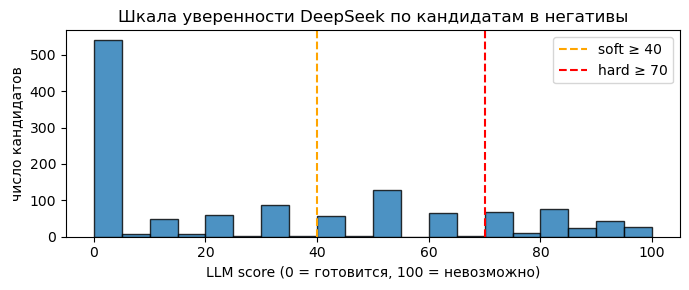

In [10]:
# === Блок C-1: наращивание корпуса негативов до 500 ===
import importlib
import recipe_negatives
importlib.reload(recipe_negatives)
from recipe_negatives import build_negative_corpus, split_corpus

CORPUS_PATH = OUT / 'negative_corpus.json'
TARGET_N = 500
HARD_THR, SOFT_THR = 70.0, 40.0

def model_p_real(rec_list):
 """P(реальный) от ингредиентного LogReg (§3.3) — для конфликт-майнинга."""
 return clf.predict_proba(features(rec_list, I_train))[:, 1]

corpus, sp = build_negative_corpus(
 recipes_tr, I_train, ing_set,
 target_n=TARGET_N,
 api_key=API_KEY, # None -> только чтение кэша, без трат токенов
 cache_path=CORPUS_PATH,
 model_score_fn=model_p_real,
 ru_fn=ru,
 hard_thr=HARD_THR, soft_thr=SOFT_THR,
 seed=SEED,
)

n_conf = len(sp['hard']) + len(sp['soft'])
print(f"\nКорпус: всего оценено {len(corpus)} | hard={len(sp['hard'])} "
 f"soft={len(sp['soft'])} rejected={len(sp['rejected'])}")
if n_conf:
 print(f"Вес одного примера в метрике: {100 / n_conf:.2f}% "
 f"(было ~3% при 34; цель < 0.5% при 500)")

if corpus:
 llm_scores = np.array([r['llm_score'] for r in corpus if r['llm_score'] is not None])
 fig, ax = plt.subplots(figsize=(7, 3))
 ax.hist(llm_scores, bins=20, edgecolor='k', alpha=0.8)
 ax.axvline(SOFT_THR, color='orange', ls='--', label=f'soft ≥ {SOFT_THR:.0f}')
 ax.axvline(HARD_THR, color='red', ls='--', label=f'hard ≥ {HARD_THR:.0f}')
 ax.set_xlabel('LLM score (0 = готовится, 100 = невозможно)')
 ax.set_ylabel('число кандидатов')
 ax.set_title('Шкала уверенности DeepSeek по кандидатам в негативы')
 ax.legend()
 plt.tight_layout()
 plt.savefig(OUT / 'negative_corpus_scores.png', dpi=120)
 plt.show()
else:
 print('Кэш пуст: задайте DEEPSEEK_API_KEY и перезапустите ячейку.')

### 3.3.6 Конфликт-майнинг и формальная метрика «сложности»

Критерий сложности: «модель считает можно» vs «DeepSeek считает нельзя».

Вводим метрику:

$$\text{difficulty} = P_{\text{model}}(\text{реальный}) \cdot \frac{\text{LLM score}}{100}$$

- difficulty → 1: модель уверена, что рецепт настоящий, а LLM уверена, что приготовить нельзя — **настоящий hard-конфликт**, на таких и надо дообучаться;
- difficulty → 0: либо модель сама видит фейк (пример лёгкий), либо LLM считает блюдо съедобным (это вообще не негатив).

Ниже — квадрант «модель vs LLM» и топ самых сложных примеров.

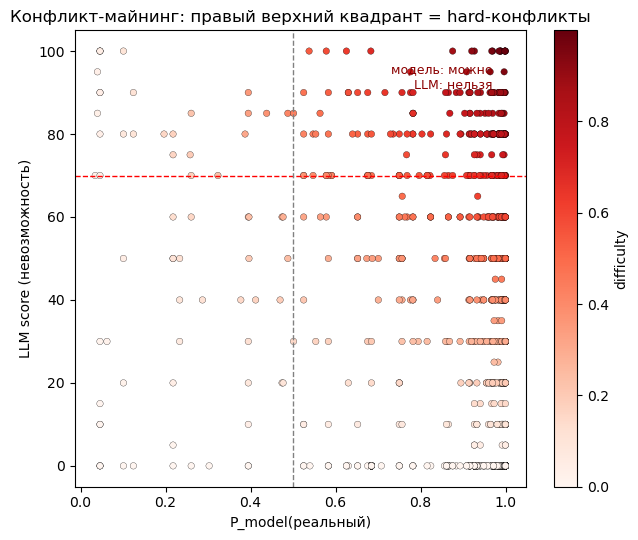

Hard-конфликтов (P_model ≥ 0.5 и LLM score ≥ 70): 218 из 1256

Топ-10 самых сложных негативов (модель «верит», LLM запрещает):


,difficulty,P_model(real),LLM score,ингредиенты
0,1.000000,1.000000,100.000000,"молоко, сливки суп из сельдерея, сливочное масло, лук"
1,0.999000,0.999000,100.000000,"молоко, вода, крахмал, ананас, сливочное масло, кетчуп, соевый соус, зелёный перец"
2,0.998000,0.998000,100.000000,"морковь, сельдерей, перец, томатный суп, ваниль, уксус, масло для салата, соль"
3,0.998000,0.998000,100.000000,"сливочный сыр, сахар, лук, ваниль"
4,0.988000,0.988000,100.000000,"вода, майонез, stalks сельдерей, молоко"
5,0.988000,0.988000,100.000000,"сливочный сыр, salad dressing, сливочное масло, молоко"
6,0.987000,0.987000,100.000000,"сливочное масло, сливочный сыр, ваниль, молоко, майонез, креветки, сельдерей, вода, зелёный лук, перец пименто"
7,0.984000,0.984000,100.000000,"крекеры, молоко, кулинарный жир, сливочный сыр, сахарная пудра, лук"
8,0.969000,0.969000,100.000000,"коричневый сахар, перец, кукурузный сироп, вода, соль, разрыхлитель, газировка"
9,0.967000,0.967000,100.000000,"перец, соль, сельдерей, разрыхлитель, красный перец, цельное kernel кукуруза, зелёный перец, маргарин, ваниль"


In [11]:
# === Блок C-2: квадрант «модель vs DeepSeek» и топ hard-конфликтов ===
if not corpus:
    print('Корпус пуст — сначала §3.3.5.')
else:
    cdf = pd.DataFrame([r for r in corpus if r['llm_score'] is not None
                        and r['model_p_real'] is not None])
    cdf['difficulty'] = cdf['model_p_real'] * cdf['llm_score'] / 100.0

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(cdf['model_p_real'], cdf['llm_score'],
                    c=cdf['difficulty'], cmap='Reds', s=22,
                    edgecolor='k', linewidth=0.2)
    ax.axhline(HARD_THR, color='red', ls='--', lw=1)
    ax.axvline(0.5, color='gray', ls='--', lw=1)
    ax.set_xlabel('P_model(реальный)')
    ax.set_ylabel('LLM score (невозможность)')
    ax.set_title('Конфликт-майнинг: правый верхний квадрант = hard-конфликты')
    ax.text(0.97, 97, 'модель: можно\nLLM: нельзя', ha='right', va='top',
            fontsize=9, color='darkred')
    plt.colorbar(sc, label='difficulty')
    plt.tight_layout()
    plt.savefig(OUT / 'conflict_mining_quadrant.png', dpi=120)
    plt.show()

    n_conflict = int(((cdf['model_p_real'] >= 0.5) & (cdf['llm_score'] >= HARD_THR)).sum())
    print(f'Hard-конфликтов (P_model ≥ 0.5 и LLM score ≥ {HARD_THR:.0f}): '
          f'{n_conflict} из {len(cdf)}')

    top = cdf.sort_values('difficulty', ascending=False).head(10)
    show = pd.DataFrame({
        'difficulty': top['difficulty'].round(3),
        'P_model(real)': top['model_p_real'].round(3),
        'LLM score': top['llm_score'].round(0),
        'ингредиенты': [', '.join(ru_list(r)) for r in top['ingredients']],
    }).reset_index(drop=True)
    print('\nТоп-10 самых сложных негативов (модель «верит», LLM запрещает):')
    with pd.option_context('display.max_colwidth', None):
        display(show.style.set_properties(subset=['ингредиенты'],
                                          **{'white-space': 'normal', 'text-align': 'left'}))


### 3.3.7 Дообучение на hard/soft корпусе и стабильность метрик

1. подтверждённые негативы (hard + soft) делим на train/test;
2. сравниваем LogReg на **сырых PPR-кандидатах** vs **LLM-корпусе** и GraphSAGE на LLM-корпусе;
3. **стабильность**: бутстреп AUC на **test-негативах** (`neg_te_c`): **34** (мини-тест до корпуса) vs **125** (25% split). Вес 0.20% при корпусе 500 — отдельно про размер корпуса, не про скоры в бутстрепе.

LLM-фильтр отбирает «кухонно невозможные», но не обязательно с низкой плотностью в `I_train` — LogReg на корпусе может **ухудшиться**, тогда как GraphSAGE использует эмбеддинги соседей и часто держится лучше.

Негативы корпуса: train=375, test=125



,обучение,acc,f1,auc
0,LogReg: PPR без LLM-фильтра,0.582,0.642,0.635
1,LogReg: LLM-корпус (hard+soft),0.542,0.697,0.533
2,GraphSAGE: LLM-корпус,0.593,0.721,0.596



LLM-корпус снижает LogReg AUC (0.635 → 0.533): подтверждённые негативы не всегда «разреженные» в I_train.
GraphSAGE на LLM-корпусе: AUC=0.596.


,негативов в бутстрепе,AUC mean,AUC std,вес 1 примера (бутстреп)
0,34,0.5325,0.0458,2.94%
1,125,0.5315,0.0236,0.80%


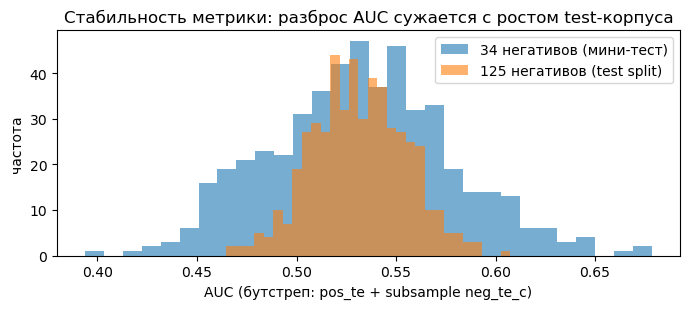


Разброс AUC (std): 0.0458 при 34 -> 0.0236 при 125 (в 1.9x уже).
Корпус 500 примеров: вес одного в полной оценке 0.20% (было ~3% при 34).


In [12]:
# === Блок C-3: дообучение на корпусе + бутстреп-стабильность ===
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split as _tts
from gnn_graph_classification import eval_graphsage_inductive_split

neg_all = [r['ingredients'] for r in sp['hard'] + sp['soft']]

if len(neg_all) < 50:
    print(f'Подтверждённых негативов пока {len(neg_all)} — для дообучения нужно '
          f'хотя бы 50. Запустите §3.3.5 с DEEPSEEK_API_KEY.')
else:
    neg_tr_c, neg_te_c = _tts(neg_all, test_size=0.25, random_state=SEED)
    pos_tr, pos_te = sub_tr, sub_te
    print(f'Негативы корпуса: train={len(neg_tr_c)}, test={len(neg_te_c)}\n')

    Xte = np.vstack([features(pos_te, I_train), features(neg_te_c, I_train)])
    yte = np.r_[np.ones(len(pos_te)), np.zeros(len(neg_te_c))]

    Xtr_old = np.vstack([features(pos_tr, I_train), features(hard_tr, I_train)])
    ytr_old = np.r_[np.ones(len(pos_tr)), np.zeros(len(hard_tr))]
    lr_old = LogisticRegression(max_iter=500).fit(Xtr_old, ytr_old)

    Xtr_new = np.vstack([features(pos_tr, I_train), features(neg_tr_c, I_train)])
    ytr_new = np.r_[np.ones(len(pos_tr)), np.zeros(len(neg_tr_c))]
    lr_new = LogisticRegression(max_iter=500).fit(Xtr_new, ytr_new)

    rows = []
    for tag, m in [('LogReg: PPR без LLM-фильтра', lr_old),
                   ('LogReg: LLM-корпус (hard+soft)', lr_new)]:
        pred = m.predict(Xte)
        rows.append({'обучение': tag,
                     'acc': accuracy_score(yte, pred),
                     'f1': f1_score(yte, pred),
                     'auc': roc_auc_score(yte, m.predict_proba(Xte)[:, 1])})

    gs_corpus = eval_graphsage_inductive_split(
        pos_tr + neg_tr_c, pos_te + neg_te_c,
        np.r_[np.ones(len(pos_tr)), np.zeros(len(neg_tr_c))].astype(int),
        np.r_[np.ones(len(pos_te)), np.zeros(len(neg_te_c))].astype(int),
        feat_graph=I_train, hidden=64, epochs=50, seed=SEED,
    )
    rows.append({'обучение': 'GraphSAGE: LLM-корпус',
                 'acc': gs_corpus.accuracy, 'f1': gs_corpus.f1, 'auc': gs_corpus.auc})
    display(pd.DataFrame(rows).round(3))

    auc_old = roc_auc_score(yte, lr_old.predict_proba(Xte)[:, 1])
    auc_new = roc_auc_score(yte, lr_new.predict_proba(Xte)[:, 1])
    if auc_new < auc_old:
        print(f'\nLLM-корпус снижает LogReg AUC ({auc_old:.3f} → {auc_new:.3f}): '
              f'подтверждённые негативы не всегда «разреженные» в I_train.')
    else:
        print(f'\nLLM-корпус улучшает LogReg AUC ({auc_old:.3f} → {auc_new:.3f}).')
    print(f'GraphSAGE на LLM-корпусе: AUC={gs_corpus.auc:.3f}.')

    rng_b = np.random.default_rng(SEED)
    pos_scores = lr_new.predict_proba(features(pos_te, I_train))[:, 1]
    neg_scores_te = lr_new.predict_proba(features(neg_te_c, I_train))[:, 1]
    N_BASELINE = 34  # размер раннего LLM-подтверждения до наращивания корпуса
    n_test_neg = len(neg_scores_te)

    def boot_auc(n_neg, n_boot=500):
        aucs = []
        n_neg = min(n_neg, n_test_neg)
        for _ in range(n_boot):
            idx = rng_b.choice(n_test_neg, size=n_neg, replace=True)
            s = np.r_[pos_scores, neg_scores_te[idx]]
            y = np.r_[np.ones(len(pos_scores)), np.zeros(n_neg)]
            aucs.append(roc_auc_score(y, s))
        return np.array(aucs)

    a_small = boot_auc(N_BASELINE)
    a_full = boot_auc(n_test_neg)
    stab = pd.DataFrame([
        {'негативов в бутстрепе': N_BASELINE, 'AUC mean': a_small.mean(), 'AUC std': a_small.std(),
         'вес 1 примера (бутстреп)': '%.2f%%' % (100 / N_BASELINE)},
        {'негативов в бутстрепе': n_test_neg, 'AUC mean': a_full.mean(),
         'AUC std': a_full.std(), 'вес 1 примера (бутстреп)': '%.2f%%' % (100 / n_test_neg)},
    ])
    display(stab.round(4))

    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hist(a_small, bins=30, alpha=0.6, label=f'{N_BASELINE} негативов (мини-тест)')
    ax.hist(a_full, bins=30, alpha=0.6, label=f'{n_test_neg} негативов (test split)')
    ax.set_xlabel('AUC (бутстреп: pos_te + subsample neg_te_c)')
    ax.set_ylabel('частота')
    ax.set_title('Стабильность метрики: разброс AUC сужается с ростом test-корпуса')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'corpus_metric_stability.png', dpi=120)
    plt.show()

    ratio = a_small.std() / max(a_full.std(), 1e-9)
    print(f'\nРазброс AUC (std): {a_small.std():.4f} при {N_BASELINE} -> {a_full.std():.4f} '
          f'при {n_test_neg} (в {ratio:.1f}x уже).')
    print(f'Корпус {len(neg_all)} примеров: вес одного в полной оценке '
          f'{100/len(neg_all):.2f}% (было ~3% при 34).')


## 3.4 Протокол оценки и ablation ингредиентных признаков

Протокол §3.3 и разбор **LogReg** по отдельным ингредиентным признакам.

Baseline и GraphSAGE — **`I_train`**. Полный `I` — §3.3.1 и §3.10.


§3.4: протокол + ablation ингредиентных признаков



,train,test,негативы
этап,,,
сплит,6245,1562,easy fake_tr / fake_te
I_train,279,—,"4,467 рёбер (только train-рецепты)"
LogReg / GraphSAGE,I_train,I_train,inductive признаки из train-графа
HeteroGAT (§3.8),полный I + feat_df,тот же граф,полный I + feat_df


,признаки,dim,acc,f1,auc
0,только несовм. пары,1,0.894,0.888,0.919
1,только odd-min,1,0.564,0.633,0.557
2,только |ингр.|,1,0.500,0.000,0.500
3,все три,3,0.884,0.879,0.938


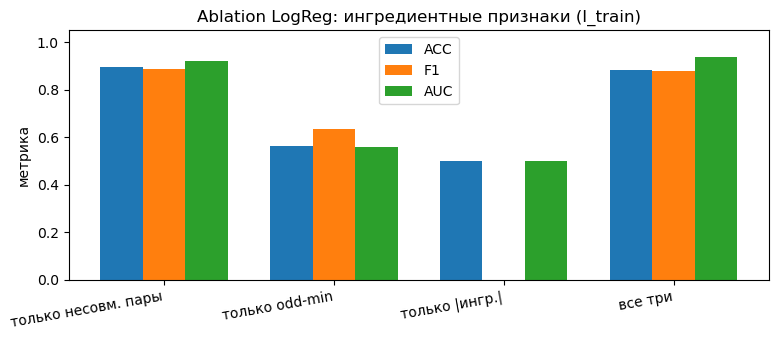

In [13]:
print('§3.4: протокол + ablation ингредиентных признаков\n')
from sklearn.metrics import f1_score

protocol = pd.DataFrame([
 {'этап': 'сплит', 'train': len(recipes_tr), 'test': len(recipes_te),
 'негативы': 'easy fake_tr / fake_te'},
 {'этап': 'I_train', 'train': I_train.number_of_nodes(), 'test': '—',
 'негативы': f'{I_train.number_of_edges():,} рёбер (только train-рецепты)'},
 {'этап': 'LogReg / GraphSAGE', 'train': 'I_train', 'test': 'I_train',
 'негативы': 'inductive признаки из train-графа'},
 {'этап': 'HeteroGAT (§3.8)', 'train': 'полный I + feat_df', 'test': 'тот же граф',
 'негативы': 'полный I + feat_df'},
])
display(protocol.set_index('этап'))

def _ing_matrix(rec_list, graph, cols):
 inc = np.array([incompat_frac(r, graph) for r in rec_list])
 odd = np.array([odd_min_score(r, graph) for r in rec_list])
 size = np.array([len(r) for r in rec_list], dtype=float)
 parts = {
 'несовм. доля': inc.reshape(-1, 1),
 'odd-min': odd.reshape(-1, 1),
 '|ингр.|': size.reshape(-1, 1),
 }
 return np.hstack([parts[c] for c in cols])

def eval_ing_ablation(cols, tag):
 Xtr = np.vstack([
 _ing_matrix(recipes_tr, I_train, cols),
 _ing_matrix(fake_tr, I_train, cols),
 ])
 ytr = np.r_[np.ones(len(recipes_tr)), np.zeros(len(fake_tr))]
 Xte = np.vstack([
 _ing_matrix(recipes_te, I_train, cols),
 _ing_matrix(fake_te, I_train, cols),
 ])
 yte = np.r_[np.ones(len(recipes_te)), np.zeros(len(fake_te))]
 c = LogisticRegression(max_iter=500).fit(Xtr, ytr)
 pred = c.predict(Xte)
 proba = c.predict_proba(Xte)[:, 1]
 return {
 'признаки': tag, 'dim': len(cols),
 'acc': accuracy_score(yte, pred),
 'f1': f1_score(yte, pred), 'auc': roc_auc_score(yte, proba),
 }

abl_ing = pd.DataFrame([
 eval_ing_ablation(['несовм. доля'], 'только несовм. пары'),
 eval_ing_ablation(['odd-min'], 'только odd-min'),
 eval_ing_ablation(['|ингр.|'], 'только |ингр.|'),
 eval_ing_ablation(['несовм. доля', 'odd-min', '|ингр.|'], 'все три'),
])
display(abl_ing.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(abl_ing))
w = 0.25
for i, m in enumerate(['acc', 'f1', 'auc']):
 ax.bar(x + (i - 1) * w, abl_ing[m], width=w, label=m.upper())
ax.set_xticks(x)
ax.set_xticklabels(abl_ing['признаки'], rotation=10, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('метрика')
ax.set_title('Ablation LogReg: ингредиентные признаки (I_train)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'ingredient_ablation.png', dpi=120)
plt.show()

## 3.8 HeteroGAT (real vs fake)

HeteroGAT на полном `I` и `feat_df` из nb02. §3.8.1 — сравнение с фиксированным split.


In [14]:
import importlib
import gnn_cuisine_classification
importlib.reload(gnn_cuisine_classification)
from gnn_cuisine_classification import build_bipartite_from_recipes, train_hetgat_cuisine

if 'feat_df' not in dir():
 feat_df = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')

G_val, recipe_ids_val, labels_val = build_bipartite_from_recipes(recipes, fake, I)
print(f'Граф: {G_val.number_of_nodes():,} узлов, {G_val.number_of_edges():,} рёбер')
print(f'Рецептов: {len(recipe_ids_val)} ({labels_val.count("real")} real, {labels_val.count("fake")} fake)')


Граф: 22,702 узлов, 113,767 рёбер
Рецептов: 15614 (7807 real, 7807 fake)


In [15]:
hg_val = train_hetgat_cuisine(
 G_nx = G_val,
 recipe_ids = recipe_ids_val,
 labels = labels_val,
 I_nx = I,
 feat_df = feat_df,
 hidden = 128,
 heads = 4,
 epochs = 80,
 lr = 3e-3,
 seed = SEED,
 verbose = True,
)
print(f'\nHeteroGAT (real vs fake):')
print(f' Accuracy: {hg_val.accuracy:.3f}')
print(f' F1: {hg_val.f1:.3f}')
print(f' AUC: {hg_val.auc:.3f}')
print()
print(hg_val.report)


  [HeteroGAT] epoch  20  loss=0.5524  val_acc=0.645
  [HeteroGAT] epoch  40  loss=0.2896  val_acc=0.931
  [HeteroGAT] epoch  60  loss=0.2373  val_acc=0.942
  [HeteroGAT] epoch  80  loss=0.2117  val_acc=0.943

HeteroGAT (real vs fake):
 Accuracy: 0.937
 F1: 0.937
 AUC: 0.983

              precision    recall  f1-score   support

        fake       0.94      0.94      0.94      1562
        real       0.94      0.94      0.94      1561

    accuracy                           0.94      3123
   macro avg       0.94      0.94      0.94      3123
weighted avg       0.94      0.94      0.94      3123



### 3.8.1 Сводное сравнение: LogReg vs GraphSAGE vs HeteroGAT

**Цель:** сравнить три архитектуры на **hard-негативах** (PPR, §3.3.2) — train и test на подвыборке `sub_tr` / `sub_te`.

1. **LogReg** — табличный baseline по признакам из `I_train`;
2. **GraphSAGE** — inductive GNN на `I_train`;
3. **HeteroGAT** — transductive GAT на полном `I` + `feat_df` (nb02, полный корпус); фиксированный split как у GraphSAGE.

Метрики на test: accuracy, F1, AUC. Контраст easy vs hard — §3.9.


3.8.1: три метода на hard-негативах (PPR)

  [HeteroGAT] epoch  20  loss=0.6630  val_acc=0.517
  [HeteroGAT] epoch  40  loss=0.6053  val_acc=0.700
  [HeteroGAT] epoch  60  loss=0.5752  val_acc=0.700
  [HeteroGAT] epoch  80  loss=0.5098  val_acc=0.683


,метод,сценарий,acc,f1,auc
0,LogReg,hard (PPR),0.583,0.622,0.621
1,GraphSAGE,hard (PPR),0.637,0.528,0.707
2,HeteroGAT,hard (transductive),0.767,0.754,0.904


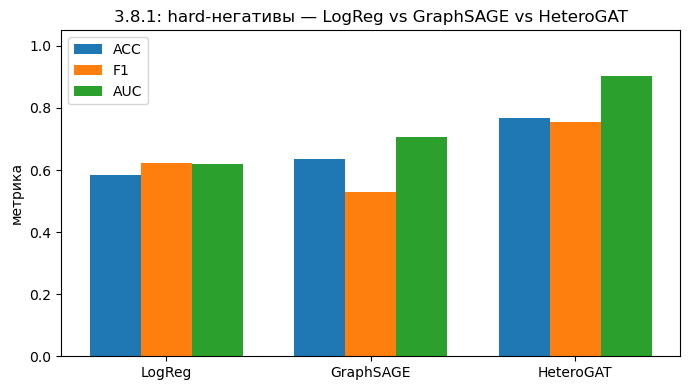


На hard GraphSAGE AUC (0.707) > LogReg (0.621).
Контраст easy vs hard (LogReg / GraphSAGE) — §3.9.


In [16]:
# === 3.8.1: сравнение LogReg, GraphSAGE и HeteroGAT на hard ===
from sklearn.metrics import f1_score

importlib.reload(gnn_graph_classification)
importlib.reload(gnn_cuisine_classification)
from gnn_graph_classification import eval_graphsage_inductive_split
from gnn_cuisine_classification import build_bipartite_from_recipes, train_hetgat_cuisine
from recipe_negatives import make_hard_fake_recipes

if 'feat_df' not in dir():
    feat_df = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')

if 'hard_tr' not in dir():
    N_HARD = 600
    sub_tr = recipes_tr[:N_HARD]
    sub_te = recipes_te[:max(1, N_HARD // 4)]
    hard_tr = make_hard_fake_recipes(sub_tr, I_train, ing_set, mix_ratio=0.4, seed=SEED)
    hard_te = make_hard_fake_recipes(sub_te, I_train, ing_set, mix_ratio=0.4, seed=SEED + 1)

print('3.8.1: три метода на hard-негативах (PPR)\n')
n_tr, n_te = len(sub_tr), len(sub_te)

Xtr_h = np.vstack([features(sub_tr, I_train), features(hard_tr, I_train)])
ytr_h = np.r_[np.ones(n_tr), np.zeros(n_tr)]
Xte_h = np.vstack([features(sub_te, I_train), features(hard_te, I_train)])
yte_h = np.r_[np.ones(n_te), np.zeros(n_te)]
clf_hard = LogisticRegression(max_iter=500).fit(Xtr_h, ytr_h)
lr_pred_h = clf_hard.predict(Xte_h)
lr_proba_h = clf_hard.predict_proba(Xte_h)[:, 1]

rec_tr_h = sub_tr + hard_tr
rec_te_h = sub_te + hard_te
gs_hard = eval_graphsage_inductive_split(
    rec_tr_h, rec_te_h,
    np.r_[np.ones(n_tr), np.zeros(n_tr)].astype(int),
    np.r_[np.ones(n_te), np.zeros(n_te)].astype(int),
    feat_graph=I_train, hidden=64, epochs=50, seed=SEED,
)

G_hard, ids_hard, labels_hard = build_bipartite_from_recipes(
    sub_tr + sub_te, hard_tr + hard_te, I,
)
tr_idx = np.r_[np.arange(n_tr), np.arange(n_tr + n_te, n_tr + n_te + n_tr)]
te_idx = np.r_[np.arange(n_tr, n_tr + n_te), np.arange(n_tr + n_te + n_tr, n_tr + n_te + n_tr + n_te)]
hg_hard = train_hetgat_cuisine(
    G_nx=G_hard,
    recipe_ids=ids_hard,
    labels=labels_hard,
    I_nx=I,
    feat_df=feat_df,
    hidden=128,
    heads=4,
    epochs=80,
    lr=3e-3,
    seed=SEED,
    train_idx=tr_idx,
    test_idx=te_idx,
    verbose=True,
)

cmp_hard = pd.DataFrame([
    {'метод': 'LogReg', 'сценарий': 'hard (PPR)',
     'acc': accuracy_score(yte_h, lr_pred_h),
     'f1': f1_score(yte_h, lr_pred_h),
     'auc': roc_auc_score(yte_h, lr_proba_h)},
    {'метод': 'GraphSAGE', 'сценарий': 'hard (PPR)',
     'acc': gs_hard.accuracy, 'f1': gs_hard.f1, 'auc': gs_hard.auc},
    {'метод': 'HeteroGAT', 'сценарий': 'hard (transductive)',
     'acc': hg_hard.accuracy, 'f1': hg_hard.f1, 'auc': hg_hard.auc},
])
display(cmp_hard.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
w = 0.25
for i, m in enumerate(['acc', 'f1', 'auc']):
    ax.bar(x + (i - 1) * w, cmp_hard[m], width=w, label=m.upper())
ax.set_xticks(x)
ax.set_xticklabels(cmp_hard['метод'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('метрика')
ax.set_title('3.8.1: hard-негативы — LogReg vs GraphSAGE vs HeteroGAT')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'validity_methods_compare.png', dpi=120)
plt.show()

lr_auc = float(cmp_hard.loc[cmp_hard['метод'] == 'LogReg', 'auc'].iloc[0])
gs_auc = float(cmp_hard.loc[cmp_hard['метод'] == 'GraphSAGE', 'auc'].iloc[0])
if gs_auc > lr_auc:
    print(f'\nНа hard GraphSAGE AUC ({gs_auc:.3f}) > LogReg ({lr_auc:.3f}).')
else:
    print(f'\nНа hard LogReg AUC ({lr_auc:.3f}) ≥ GraphSAGE ({gs_auc:.3f}).')
print('Контраст easy vs hard (LogReg / GraphSAGE) — §3.9.')


## 3.9 Контраст easy vs hard: LogReg и GraphSAGE

> Полное сравнение **трёх** архитектур на hard — §3.8.1. Здесь — насколько падают метрики при переходе с easy на hard.


In [17]:
from gnn_graph_classification import eval_graphsage_inductive_split

def ing_on(neg_tr, neg_te):
    Xtr = np.vstack([features(sub_tr, I_train), features(neg_tr, I_train)])
    ytr = np.r_[np.ones(len(sub_tr)), np.zeros(len(neg_tr))]
    Xte = np.vstack([features(sub_te, I_train), features(neg_te, I_train)])
    yte = np.r_[np.ones(len(sub_te)), np.zeros(len(neg_te))]
    m = LogisticRegression(max_iter=500).fit(Xtr, ytr)
    return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

def gs_on(neg_tr, neg_te):
    rec_tr = sub_tr + neg_tr
    rec_te = sub_te + neg_te
    y_tr = np.r_[np.ones(len(sub_tr)), np.zeros(len(neg_tr))].astype(int)
    y_te = np.r_[np.ones(len(sub_te)), np.zeros(len(neg_te))].astype(int)
    return eval_graphsage_inductive_split(
        rec_tr, rec_te, y_tr, y_te,
        feat_graph=I_train, hidden=64, epochs=40, seed=SEED,
    ).auc

trained_cmp = pd.DataFrame([
    {'обучены и тест на': 'easy (random)',
     'несовм. пары AUC': round(ing_on(easy_tr, easy_te), 3),
     'GraphSAGE AUC': round(gs_on(easy_tr, easy_te), 3)},
    {'обучены и тест на': 'hard (PPR)',
     'несовм. пары AUC': round(ing_on(hard_tr, hard_te), 3),
     'GraphSAGE AUC': round(gs_on(hard_tr, hard_te), 3)},
])
display(trained_cmp)


,обучены и тест на,несовм. пары AUC,GraphSAGE AUC
0,easy (random),0.941,0.910
1,hard (PPR),0.621,0.698


## 3.10 Объяснение состава по графу I

Post-hoc интерпретация (не метрики модели): используем **полный** `I` из nb01 — «пары, которые никогда не встречались в корпусе RecipeNLG».  
Модели §3.3–3.8 обучались на **`I_train`**; здесь намеренно другой граф для человекочитаемого объяснения.


In [18]:
def find_odd_ingredient(recipe_ings, I, top_k=3):
    """Ингредиент с минимальной связностью с остальными (post-hoc, полный граф I)."""
    ings = list(dict.fromkeys(x for x in recipe_ings if x in I))
    if len(ings) < 2:
        return []
    scores = {}
    for ing in ings:
        others = [x for x in ings if x != ing]
        if not others:
            continue
        cn_sum = sum(
            len(set(I.neighbors(ing)) & set(I.neighbors(o)))
            for o in others
        )
        scores[ing] = cn_sum / len(others)
    return sorted(scores, key=scores.get)[:top_k]

print('── Интерпретация фейковых рецептов ──\n')
for i in range(5):
    r = fake[i]
    bad_pairs = incompatible_pairs(r, I)
    odd_ings = find_odd_ingredient(r, I)

    print(f'Фейк #{i+1}: {ru_list(r[:8])}')
    print(f' Плотность связей: {edge_density(r, I):.3f}')

    if bad_pairs:
        shown = [f'{ru(a)} + {ru(b)}' for a, b in bad_pairs]
        print(f' Несовместимые пары ({len(bad_pairs)}): {", ".join(shown)}')

    if odd_ings:
        print(f' Ингредиент-аутсайдер: {ru_list(odd_ings)}')
    print()


── Интерпретация фейковых рецептов ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
 Плотность связей: 0.500
 Несовместимые пары (5): сливочное масло + черничный йогурт, коричневый сахар + черничный йогурт, орехи + зернистая горчица, орехи + черничный йогурт, зернистая горчица + черничный йогурт
 Ингредиент-аутсайдер: ['черничный йогурт', 'зернистая горчица', 'орехи']

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
 Плотность связей: 0.167
 Несовместимые пары (5): говядина + цельные семена кориандра, говядина + четвертинки помидоров черри, сметана + цельные семена кориандра, сметана + четвертинки помидоров черри, цельные семена кориандра + четвертинки помидоров черри
 Ингредиент-аутсайдер: ['цельные семена кориандра', 'четвертинки помидоров черри', 'говядина']

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая сухая горч

## 3.11 SHAP: baseline по несовместимым парам (§3.3)

Вклад **доли несовместимых пар** и **размера рецепта** в предсказание LogReg.


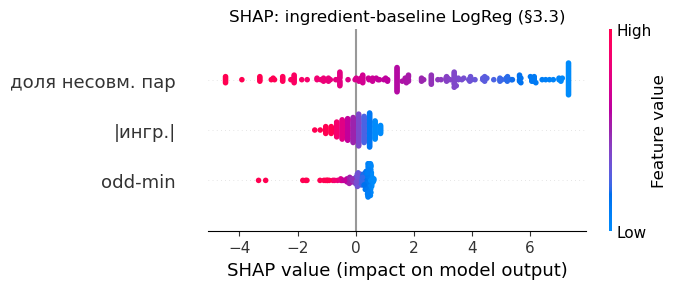

Фейк: ['ванильный пудинг быстрого приготовления', 'ананас', 'сливочный сыр', 'семена аннато', 'зира']
Предсказание: реальный
SHAP-вклад (+ = к реальному, − = к фейку):
 доля несовм. пар     -0.9391
 odd-min              +0.5733
 |ингр.|              +0.4774


In [19]:
import warnings
import shap

ING_FEAT = ['доля несовм. пар', 'odd-min', '|ингр.|']

explainer = shap.LinearExplainer(clf, X_tr, feature_names=ING_FEAT)
shap_vals = explainer(X_te[:200])

with warnings.catch_warnings():
 warnings.filterwarnings(
 'ignore', category=FutureWarning,
 message=r'.*NumPy global RNG was seeded.*',
 )
 shap.summary_plot(shap_vals, X_te[:200], feature_names=ING_FEAT,
 show=False, plot_size=(7, 3))
plt.title('SHAP: ingredient-baseline LogReg (§3.3)')
plt.tight_layout()
plt.savefig(OUT / 'shap_summary.png', dpi=120)
plt.show()

i_explain = 0
x_fake = features([fake_te[i_explain]], I_train)
sv_one = explainer(x_fake)
print(f'Фейк: {ru_list(fake_te[i_explain][:8])}')
print(f'Предсказание: {"реальный" if clf.predict(x_fake)[0] == 1 else "фейк"}')
print('SHAP-вклад (+ = к реальному, − = к фейку):')
for feat, val in sorted(zip(ING_FEAT, sv_one.values[0]), key=lambda x: abs(x[1]), reverse=True):
 sign = '+' if val > 0 else '-'
 print(f' {feat:<20} {sign}{abs(val):.4f}')


## 3.13 Какие ингредиенты HeteroGAT учитывает сильнее (интерпретация модели real vs fake)

In [20]:
from gnn_cuisine_classification import top_attention_ingredients

print('── HeteroGAT: ингредиенты по важности для решения ──\n')
n_real = len(recipes)
for k in range(3):
    ridx = n_real + k
    top = top_attention_ingredients(
        hg_val.model, hg_val.data, ridx, hg_val.ing_names, top_k=5,
    )
    print(f'Фейк #{k+1}: {ru_list(fake[k][:8])}')
    for name, score in top:
        bar = '█' * int(score * 30)
        print(f' attn={score:.3f} {bar} {ru(name)}')
    print()


── HeteroGAT: ингредиенты по важности для решения ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
 attn=0.785 ███████████████████████ сливочное масло
 attn=0.077 ██ коричневый сахар
 attn=0.053 █ орехи
 attn=0.043 █ зернистая горчица
 attn=0.042 █ черничный йогурт

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
 attn=0.779 ███████████████████████ сметана
 attn=0.109 ███ говядина
 attn=0.057 █ четвертинки помидоров черри
 attn=0.056 █ цельные семена кориандра

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая сухая горчица']
 attn=0.778 ███████████████████████ сливочное масло
 attn=0.079 ██ перец
 attn=0.040 █ чесночный порошок
 attn=0.035 █ пюре быстрого приготовления
 attn=0.035 █ свежие томатильо



## 3.14 GraphSAGE: среднее по ингредиентам

GraphSAGE на **`I_train`**, readout=`mean` (среднее по ингредиентам).



In [21]:
import importlib, gnn_graph_classification
importlib.reload(gnn_graph_classification)
from gnn_graph_classification import train_graphsage_validity_inductive

all_recipes = recipes + fake
y_all = np.r_[np.ones(len(recipes)), np.zeros(len(fake))].astype(int)

gs_pool = train_graphsage_validity_inductive(
    all_recipes, y_all, feat_graph=I_train, hidden=64, epochs=50, seed=SEED, readout='mean',
)
print('GraphSAGE, среднее по ингредиентам (real vs fake), inductive:')
print(f' Accuracy: {gs_pool.accuracy:.3f}')
print(f' F1: {gs_pool.f1:.3f}')
print(f' AUC: {gs_pool.auc:.3f}')


GraphSAGE, среднее по ингредиентам (real vs fake), inductive:
 Accuracy: 0.852
 F1: 0.856
 AUC: 0.928


## 3.15 Counterfactual: подмена/удаление ингредиента → рост P(фейк)

Берём модель из §3.14 (`feat_graph=I_train`). Counterfactual-граф — тот же **`I_train`**, не полный `I`.

In [22]:
from gnn_graph_classification import counterfactual_culprits

print('── Counterfactual: убираем ингредиент → как меняется P(фейк) ──\n')
for k in range(3):
    base, culprits = counterfactual_culprits(gs_pool.model, fake[k], I_train)
    if base is None:
        continue
    print(f'Фейк #{k+1}: {ru_list(fake[k][:8])}')
    print(f' P(фейк) исходно: {base:.3f}')
    for ing, delta in culprits[:3]:
        arrow = 'снижает фейк' if delta > 0 else 'повышает фейк'
        print(f' убрать {ru(ing):<22} Δ={delta:+.3f} ({arrow})')
    print()


── Counterfactual: убираем ингредиент → как меняется P(фейк) ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
 P(фейк) исходно: 0.030
 убрать орехи                  Δ=+0.003 (снижает фейк)
 убрать коричневый сахар       Δ=+0.001 (снижает фейк)
 убрать сливочное масло        Δ=-0.005 (повышает фейк)

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
 P(фейк) исходно: 0.063
 убрать говядина               Δ=+0.029 (снижает фейк)
 убрать сметана                Δ=-0.050 (повышает фейк)

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая сухая горчица']
 P(фейк) исходно: 0.032
 убрать чесночный порошок      Δ=+0.007 (снижает фейк)
 убрать перец                  Δ=-0.003 (повышает фейк)
 убрать сливочное масло        Δ=-0.006 (повышает фейк)

